In [1]:
import numpy as np
from datetime import timedelta
from glob import glob
import matplotlib.pyplot as plt
import xarray as xr
import os

def u2rho_2d (var_u):
    [Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[:,1:-1]=0.5*(var_u[:,1:]+var_u[:,:-1])
    var_rho[:,0]=var_rho[:,1]
    var_rho[:,-1]=var_rho[:,-2]
    return var_rho
    
def v2rho_2d (var_v):
    [M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((Mp,Lp))
    var_rho[1:-1,:]=0.5*(var_v[1:,:]+var_v[:-1,:])
    var_rho[0,:]=var_rho[1,:]
    var_rho[-1,:]=var_rho[-2,:]
    return var_rho

def u2rho_3d (var_u):
    [N,Mp,L]=var_u.shape
    Lp=L+1
    Lm=L-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,:,1:-1]=0.5*(var_u[:,:,1:]+var_u[:,:,:-1])
    var_rho[:,:,0]=var_rho[:,:,1]
    var_rho[:,:,-1]=var_rho[:,:,-2]
    return var_rho
    
def v2rho_3d (var_v):
    [N,M,Lp]=var_v.shape
    Mp=M+1
    Mm=M-1
    var_rho=np.zeros((N,Mp,Lp))
    var_rho[:,1:-1,:]=0.5*(var_v[:,1:,:]+var_v[:,:-1,:])
    var_rho[:,0,:]=var_rho[:,1,:]
    var_rho[:,-1,:]=var_rho[:,-2,:]
    return var_rho

def spheric_dist(lat1, lat2, lon1, lon2):
    """
    Compute the spherical distance between two points on Earth.
    
    Parameters:
    lat1, lat2 : array-like
        Latitude of the two points (in degrees).
    lon1, lon2 : array-like
        Longitude of the two points (in degrees).
    
    Returns:
    dist : array-like
        The spherical distance between the points (in meters).
    """
    
    # Earth radius in meters
    R = 6367442.76
    
    # Determine proper longitudinal shift
    l = np.abs(lon2 - lon1)
    l[l >= 180] = 360 - l[l >= 180]
    
    # Convert decimal degrees to radians
    deg2rad = np.pi / 180
    lat1 = lat1 * deg2rad
    lat2 = lat2 * deg2rad
    l = l * deg2rad
    
    # Compute the distances
    dist = R * np.arcsin(np.sqrt(((np.sin(l) * np.cos(lat2)) ** 2) + 
                                 ((np.sin(lat2) * np.cos(lat1)) - 
                                  (np.sin(lat1) * np.cos(lat2) * np.cos(l))) ** 2))
    
    return dist

def spheric_dist_one(lat1, lat2, lon1, lon2):
    """计算两个经纬度点之间的球面距离（标量版）"""
    # 处理经度差
    l = np.abs(lon2 - lon1)
    if l >= 180:
        l = 360 - l
    
    # 转换为弧度
    deg2rad = np.pi / 180
    lat1_rad = lat1 * deg2rad
    lat2_rad = lat2 * deg2rad
    l_rad = l * deg2rad
    
    # 球面距离公式
    distance = 6371 * np.arccos(
        np.sin(lat1_rad) * np.sin(lat2_rad) + 
        np.cos(lat1_rad) * np.cos(lat2_rad) * np.cos(l_rad)
    )
    return distance
def transunit_spher2flat(u,v,lat):
    v1=v*1852*60
    u1=u*1852*60*np.cos(lat*np.pi/180)
    return u1,v1


import scipy.signal as sig
import numpy as np
import math
from scipy.special import jv # Imports Bessel function 
import matplotlib.pyplot as plt
from scipy.stats import chi2

def spectralFlux(un, vn, x, y, wind, detr):
    ''' CALCULATES SPECTRAL FLUXES USING CONVENTIONAL METHOD (Ayaji et al. 2019)
        Input:
        un, vn: horizontal velocity components (gridded)
        x, y: distance vectors in meters
        wind: if == 1, windowing is performed
        detr: if == 1, trend and mean are removed '''
    from scipy.signal.windows import hann

    Nx = len(x)
    Ny = len(y)
    
    # Removes trends and mean
    if detr == 1:
        un = un - np.mean(un)
        vn = vn - np.mean(vn)
        un = sig.detrend(un, axis=0, type='linear')
        un = sig.detrend(un, axis=1, type='linear')
        vn = sig.detrend(vn, axis=0, type='linear')
        vn = sig.detrend(vn, axis=1, type='linear')

    # Windowing
    if wind == 1:
        Nx, Ny = un.shape
        # hannx = sig.hann(Nx, sym=False)
        # hanny = sig.hann(Ny, sym=False)
        hannx = hann(Nx, sym=False)
        hanny = hann(Ny, sym=False)
        hann = hannx[np.newaxis, ...]*hanny[..., np.newaxis]
        un *= hann
        vn *= hann

    dx = np.mean(np.diff(x, axis=0))
    dy = np.mean(np.diff(y, axis=0))
    
    # Defines wavenumbers
    kx = np.fft.fftfreq(Nx, dx)
    ky = np.fft.fftfreq(Ny, dy)
    Kmax = max(kx.max(), ky.max())
    kk, ll = np.meshgrid(kx, ky)
    K2D = np.sqrt(kk**2 + ll**2)
    ddk = 1./(dx*Nx)
    ddl = 1./(dy*Ny)
    dK = max(ddk, ddl)
    K1D = dK*np.arange(1, int(Kmax/dK))


    # Calculates divergences in fourier space \int^{k_max}_0 \nabla u e^{-ikx}dx = k*\int^{k_max}_0 u e^{-ikx}dx
    dudx = np.real(np.fft.ifft2(np.fft.fft2(un)*(1j*kx*2*np.pi)[None, :]));
    dudy = np.real(np.fft.ifft2(np.fft.fft2(un)*(1j*ky*2*np.pi)[:, None]));
    dvdx = np.real(np.fft.ifft2(np.fft.fft2(vn)*(1j*kx*2*np.pi)[None, :]));
    dvdy = np.real(np.fft.ifft2(np.fft.fft2(vn)*(1j*ky*2*np.pi)[:, None]));
    # dudx = np.real(np.fft.ifft2(np.fft.fft2(un)*(1j*kx)[None, :]));
    # dudy = np.real(np.fft.ifft2(np.fft.fft2(un)*(1j*ky)[:, None]));
    # dvdx = np.real(np.fft.ifft2(np.fft.fft2(vn)*(1j*kx)[None, :]));
    # dvdy = np.real(np.fft.ifft2(np.fft.fft2(vn)*(1j*ky)[:, None]));

    # Multiplies by complex conjugate of velocity
    t1 = un*dudx + vn*dudy
    t2 = un*dvdx + vn*dvdy

    # Fourier transform and complex conjugate
    KEtrans = (np.fft.fft2(un).conj())*np.fft.fft2(t1) + (np.fft.fft2(vn).conj())*np.fft.fft2(t2)
    KEtransf2D = -np.real(KEtrans)/np.square(Nx*Ny)
#     specflux = np.zeros(len(K1D))
    
#     for i in range(K1D.size):
#         kfilt =  ((K1D[i]  <= K2D))
#         specflux[i] = (KEdiv2D[kfilt]).sum()

    transfer = np.zeros(len(K1D))
    # for i in range(K1D.size):
    #     kfilt =  ((K1D[i] - K1D[0]) < K2D) & (K2D <= K1D[i])
    #     transfer[i] = (KEtransf2D[kfilt]).sum()

    for i in range(K1D.size):
        kmin = K1D[i] - 0.5 * dK
        kmax = K1D[i] + 0.5 * dK
        kfilt = (K2D >= kmin) & (K2D < kmax)
        transfer[i] = KEtransf2D[kfilt].sum()
    
    specflux = np.cumsum(transfer[::-1])[::-1] # - Get flux
    divFlux = transfer
    
    return K1D, specflux, divFlux

def spectralwindwork(un, vn, tau_u, tau_v , x, y, wind, detr):
    ''' CALCULATES SPECTRAL FLUXES USING CONVENTIONAL METHOD (Ayaji et al. 2019)
        modified by zsm
        Input:
        un, vn: horizontal velocity components (gridded)
        x, y: distance vectors in meters
        wind: if == 1, windowing is performed
        detr: if == 1, trend and mean are removed '''
    from scipy.signal.windows import hann

    Nx = len(x)
    Ny = len(y)
    
    # Removes trends and mean
    if detr == 1:
        un = un - np.mean(un)
        vn = vn - np.mean(vn)
        un = sig.detrend(un, axis=0, type='linear')
        un = sig.detrend(un, axis=1, type='linear')
        vn = sig.detrend(vn, axis=0, type='linear')
        vn = sig.detrend(vn, axis=1, type='linear')

        tau_u = tau_u - np.mean(tau_u)
        tau_v = tau_v - np.mean(tau_v)
        tau_u = sig.detrend(tau_u, axis=0, type='linear')
        tau_u = sig.detrend(tau_u, axis=1, type='linear')
        tau_v = sig.detrend(tau_v, axis=0, type='linear')
        tau_v = sig.detrend(tau_v, axis=1, type='linear')

    # Windowing
    if wind == 1:
        Nx, Ny = un.shape
        # hannx = sig.hann(Nx, sym=False)
        # hanny = sig.hann(Ny, sym=False)
        hannx = hann(Nx, sym=False)
        hanny = hann(Ny, sym=False)
        hann = hannx[np.newaxis, ...]*hanny[..., np.newaxis]
        un *= hann
        vn *= hann
        tau_u *=hann
        tau_v *=hann

    dx = np.mean(np.diff(x, axis=0))
    dy = np.mean(np.diff(y, axis=0))
    
    # Defines wavenumbers
    kx = np.fft.fftfreq(Nx, dx)
    ky = np.fft.fftfreq(Ny, dy)
    Kmax = max(kx.max(), ky.max())
    kk, ll = np.meshgrid(kx, ky)
    K2D = np.sqrt(kk**2 + ll**2)
    ddk = 1./(dx*Nx)
    ddl = 1./(dy*Ny)
    dK = max(ddk, ddl)
    K1D = dK*np.arange(1, int(Kmax/dK))


    # Fourier transform and complex conjugate
    WindWork = (np.fft.fft2(un).conj())*np.fft.fft2(tau_u) + (np.fft.fft2(vn).conj())*np.fft.fft2(tau_v)
    WindWork2D = np.real(WindWork)/np.square(Nx*Ny)


    ww = np.zeros(len(K1D))

    for i in range(K1D.size):
        kmin = K1D[i] - 0.5 * dK
        kmax = K1D[i] + 0.5 * dK
        kfilt = (K2D >= kmin) & (K2D < kmax)
        ww[i] = WindWork2D[kfilt].sum()
    
    
    return K1D, ww

import scipy.io as sio

In [ ]:
data_dir='/meddy/simingzhang/Data/RB_iceland_data/'
gname='niskin2km_500m_grd.nc'
grid=xr.open_dataset(data_dir+gname)
pm=grid['pm'].values
pn=grid['pn'].values
dx=np.mean([1/pm,1/pn])
x=(np.arange(pm.shape[0])+1)*dx
y=x

# HF

In [2]:
fname='iceland_wave/z_niskin2km_his_hf_depth_500m_grd.0002.nc'
windname='iceland_wave/samp_wind_stress_winter_hf_2k_500m_grd.nc'
ds=xr.open_dataset(data_dir+windname)

u_w=ds['uw'].values
v_w=ds['vw'].values
Tau_u=ds['stress_u'].values
Tau_v=ds['stress_v'].values

In [7]:
un=u_w
vn=v_w

# param
wind = 1  # no windowing
detr = 1  # no detrend

Nx, Ny = un[0,:,:].shape

dx = np.mean(np.diff(x, axis=0))
dy = np.mean(np.diff(y, axis=0))

# Defines wavenumbers
kx = np.fft.fftfreq(Nx, dx)
ky = np.fft.fftfreq(Ny, dy)
Kmax = max(kx.max(), ky.max())
kk, ll = np.meshgrid(kx, ky)
K2D = np.sqrt(kk**2 + ll**2)
ddk = 1./(dx*Nx)
ddl = 1./(dy*Ny)
dK0 = max(ddk, ddl)
K1D0 = dK0*np.arange(1, int(Kmax/dK0))

# Calculates spectral flux
Nk = len(K1D0)
Nt = (un.shape[0])


In [8]:
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from tqdm import tqdm



# Convert xarray to numpy once
un_np = un
vn_np = vn

def calculate_flux(ii):
    return spectralFlux(un_np[ii, :, :], vn_np[ii, :, :], x, y, wind, detr)

with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(calculate_flux, range(Nt)), total=Nt))

# Unpack results from ProcessPoolExecutor
K1D_list = []
specflux_list = []
divFlux_list = []

for K1D_i, specflux_i, divFlux_i in results:
    K1D_list.append(K1D_i)
    specflux_list.append(specflux_i)
    divFlux_list.append(divFlux_i)

# Convert to arrays
specflux_arr = np.vstack(specflux_list)    # shape: (Nt, Nk)
divFlux_arr   = np.vstack(divFlux_list)    # shape: (Nt, Nk)

# K1D should be identical for all times
K1D = K1D_list[0]

# Compute mean and std along time
specFlux_mean = np.mean(specflux_arr, axis=0)
specFlux_std  = np.std(specflux_arr, axis=0)

divFlux_mean = np.mean(divFlux_arr, axis=0)
divFlux_std  = np.std(divFlux_arr, axis=0)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2100/2100 [01:45<00:00, 19.91it/s]


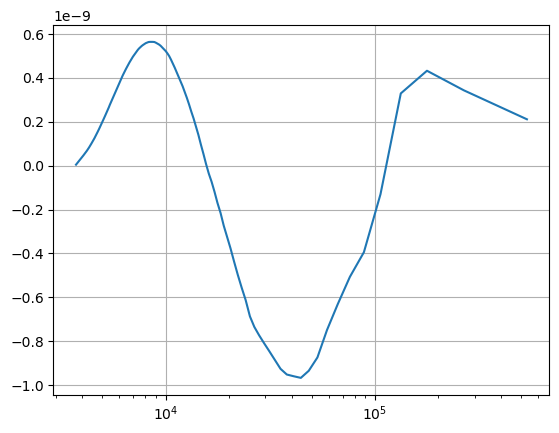

In [9]:
plt.semilogx(1/K1D,specFlux_mean)
plt.grid(True)
plt.show()

In [10]:
def calculate_ww(ii):
    return spectralwindwork(un_np[ii, :, :], vn_np[ii, :, :], Tau_u[ii, :, :], Tau_v[ii, :, :], x, y, wind, detr)

with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(calculate_ww, range(Nt)), total=Nt))

# Unpack results from ProcessPoolExecutor
K1D_list = []
ww_list = []

for K1D_i, ww_i in results:
    K1D_list.append(K1D_i)
    ww_list.append(ww_i)

# Convert to arrays
ww_arr = np.vstack(ww_list)    # shape: (Nt, Nk)

# K1D should be identical for all times
K1D = K1D_list[0]

# Compute mean and std along time
ww_mean = np.mean(ww_arr, axis=0)
ww_std  = np.std(ww_arr, axis=0)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2100/2100 [04:12<00:00,  8.33it/s]


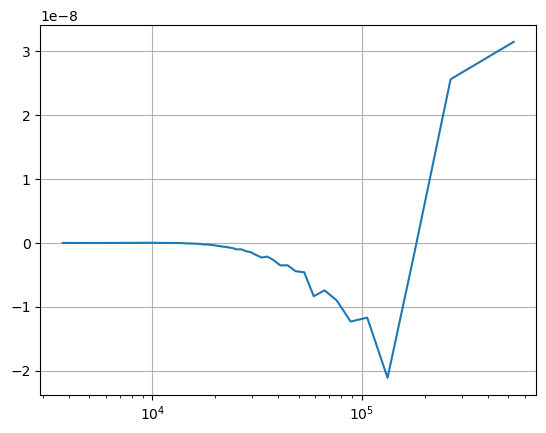

In [11]:
plt.semilogx(1/K1D,ww_mean)
plt.grid(True)
plt.show()

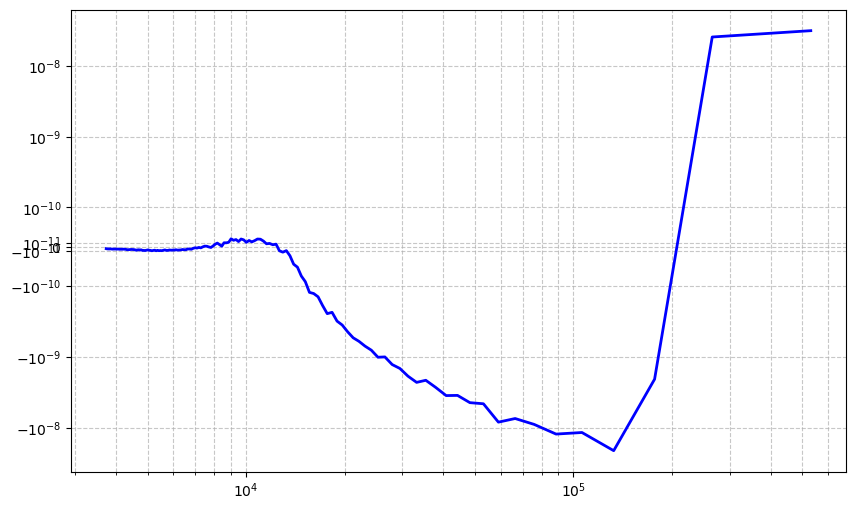

In [12]:
plt.figure(figsize=(10, 6))
plt.yscale('symlog', linthresh=1e-10, linscale=0.5)
plt.semilogx(1/K1D, ww_mean, 'b-', linewidth=2)
plt.grid(True, which="both", linestyle='--', alpha=0.7)

In [14]:
sio.savemat('HF_cospec_windwork.mat',{'K1D':K1D,'ww_mean':ww_mean})

# SM

In [16]:
fname='iceland_no_wave/z_niskin2km_his_smooth_depth_500m_grd.0002.nc'
windname='iceland_no_wave/samp_wind_stress_winter_smooth_2k_500m_grd.nc'
ds=xr.open_dataset(data_dir+windname)


Tau_u=u2rho_3d(ds['sustr'].values)/1025
Tau_v=v2rho_3d(ds['svstr'].values)/1025

dU=xr.open_dataset(data_dir+fname)
u_w=u2rho_3d(np.squeeze(dU['u'].values)[0:1596,:,:])
v_w=v2rho_3d(np.squeeze(dU['v'].values)[0:1596,:,:])

In [18]:
Tau_u.shape

(1596, 287, 287)

In [ ]:
un=u_w
vn=v_w

# param
wind = 1  # no windowing
detr = 1  # no detrend

Nx, Ny = un[0,:,:].shape

dx = np.mean(np.diff(x, axis=0))
dy = np.mean(np.diff(y, axis=0))

# Defines wavenumbers
kx = np.fft.fftfreq(Nx, dx)
ky = np.fft.fftfreq(Ny, dy)
Kmax = max(kx.max(), ky.max())
kk, ll = np.meshgrid(kx, ky)
K2D = np.sqrt(kk**2 + ll**2)
ddk = 1./(dx*Nx)
ddl = 1./(dy*Ny)
dK0 = max(ddk, ddl)
K1D0 = dK0*np.arange(1, int(Kmax/dK0))

# Calculates spectral flux
Nk = len(K1D0)
Nt = (un.shape[0])


In [ ]:
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
from tqdm import tqdm



# Convert xarray to numpy once
un_np = un
vn_np = vn

def calculate_flux(ii):
    return spectralFlux(un_np[ii, :, :], vn_np[ii, :, :], x, y, wind, detr)

with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(calculate_flux, range(Nt)), total=Nt))

# Unpack results from ProcessPoolExecutor
K1D_list = []
specflux_list = []
divFlux_list = []

for K1D_i, specflux_i, divFlux_i in results:
    K1D_list.append(K1D_i)
    specflux_list.append(specflux_i)
    divFlux_list.append(divFlux_i)

# Convert to arrays
specflux_arr = np.vstack(specflux_list)    # shape: (Nt, Nk)
divFlux_arr   = np.vstack(divFlux_list)    # shape: (Nt, Nk)

# K1D should be identical for all times
K1D = K1D_list[0]

# Compute mean and std along time
specFlux_mean = np.mean(specflux_arr, axis=0)
specFlux_std  = np.std(specflux_arr, axis=0)

divFlux_mean = np.mean(divFlux_arr, axis=0)
divFlux_std  = np.std(divFlux_arr, axis=0)

In [ ]:
plt.semilogx(1/K1D,specFlux_mean)
plt.grid(True)
plt.show()

In [ ]:
def calculate_ww(ii):
    return spectralwindwork(un_np[ii, :, :], vn_np[ii, :, :], Tau_u[ii, :, :], Tau_v[ii, :, :], x, y, wind, detr)

with ProcessPoolExecutor() as executor:
    results = list(tqdm(executor.map(calculate_ww, range(Nt)), total=Nt))

# Unpack results from ProcessPoolExecutor
K1D_list = []
ww_list = []

for K1D_i, ww_i in results:
    K1D_list.append(K1D_i)
    ww_list.append(ww_i)

# Convert to arrays
ww_arr = np.vstack(ww_list)    # shape: (Nt, Nk)

# K1D should be identical for all times
K1D = K1D_list[0]

# Compute mean and std along time
ww_mean = np.mean(ww_arr, axis=0)
ww_std  = np.std(ww_arr, axis=0)


In [ ]:
plt.semilogx(1/K1D,ww_mean)
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.yscale('symlog', linthresh=1e-10, linscale=0.5)
plt.semilogx(1/K1D, ww_mean, 'b-', linewidth=2)
plt.grid(True, which="both", linestyle='--', alpha=0.7)

In [ ]:
sio.savemat('SM_cospec_windwork.mat',{'K1D':K1D,'ww_mean':ww_mean})